In [4]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap
import dice_ml
from dice_ml import Dice
import warnings

In [5]:
df = pd.read_csv('processed_student_data.csv')
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

model = joblib.load('student_performance_model.pkl')
feature_names = joblib.load('feature_names.pkl')

print("Model and data loaded successfully")
print("Features:", X.shape[1])

Model and data loaded successfully
Features: 34


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle est

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print("SHAP values computed successfully")
print("Shape:", shap_values.shape)

SHAP values computed successfully
Shape: (6607, 34)


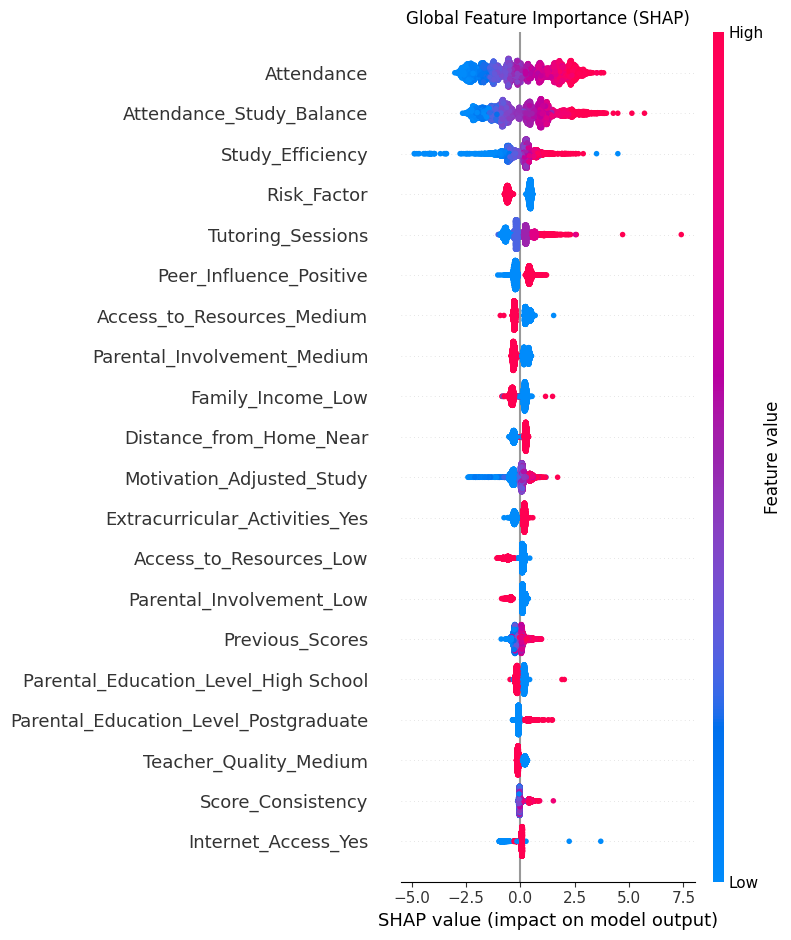

Saved: shap_summary.png


In [ ]:
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: shap_summary.png")

In [10]:
print(type(shap_values))
print(len(shap_values))
print(type(explainer.expected_value))
print(explainer.expected_value)

<class 'numpy.ndarray'>
6607
<class 'numpy.ndarray'>
[67.23680796]


<Figure size 640x480 with 0 Axes>

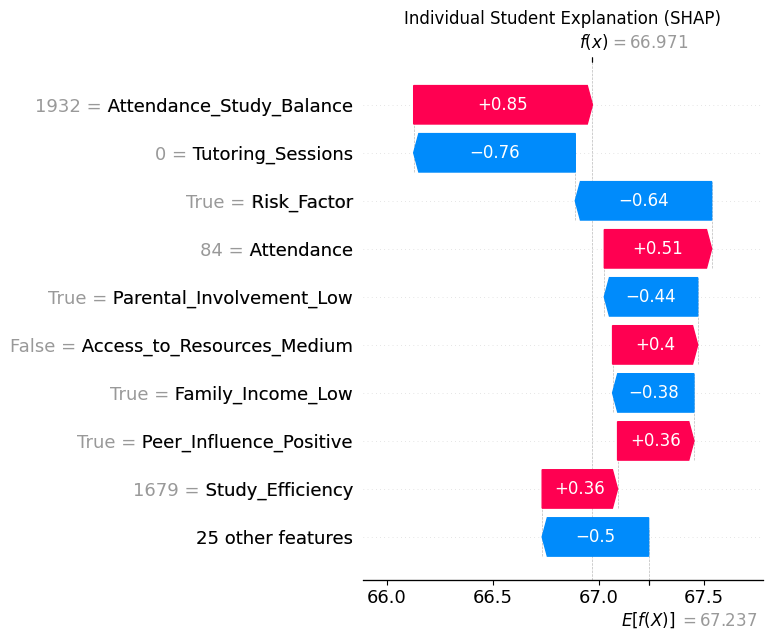

Saved: shap_waterfall.png


In [11]:
#explain prediction for first student in dataset
student_index = 0
shap_exp = shap.Explanation(
    values=shap_values[student_index],
    base_values=explainer.expected_value[0],
    data=X.iloc[student_index],
    feature_names=list(X.columns)
)

plt.figure()
shap.plots.waterfall(shap_exp, show=False)
plt.title('Individual Student Explanation (SHAP)')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall.png")

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Convert all boolean columns to int
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# DiCE needs a combined dataframe
train_df = X_train.copy()
train_df['Exam_Score'] = y_train.values

dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=list(X_train.columns),
    outcome_name='Exam_Score'
)

print("DiCE dataset prepared")

DiCE dataset prepared


In [13]:
dice_model = dice_ml.Model(model=model, backend='sklearn', model_type='regressor')
dice_exp = Dice(dice_data, dice_model, method='random')

print("DiCE explainer ready")

DiCE explainer ready


In [14]:
query_instance = X_test.iloc[0:1]

print("Student actual score:", y_test.iloc[0])
print("Student predicted score:", model.predict(query_instance)[0].round(2))
print()

cf = dice_exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_range=[75, 100]
)

cf.visualize_as_dataframe(show_only_changes=True)

Student actual score: 65
Student predicted score: 64.53



100%|██████████| 1/1 [00:00<00:00,  1.71it/s]

Query instance (original outcome : 65.0)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Distance_from_Home_Near,Gender_Male,Study_Efficiency,Wellness,Study_Intensity,Attendance_Study_Balance,Score_Consistency,Risk_Factor,Motivation_Adjusted_Study,Exam_Score
0,20.0,71.0,7.0,87.0,1.0,5.0,0.0,1.0,1.0,0.0,...,1.0,1.0,1740.0,35.0,2.5,1420.0,67.0,1.0,40.0,65.0



Diverse Counterfactual set (new outcome: [75, 100])


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Distance_from_Home_Near,Gender_Male,Study_Efficiency,Wellness,Study_Intensity,Attendance_Study_Balance,Score_Consistency,Risk_Factor,Motivation_Adjusted_Study,Exam_Score
0,-,87.8,-,-,6.6,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,75.38409423828125
1,-,98.8,-,-,-,-,-,-,-,-,...,-,0.3,-,-,0.5,-,-,-,-,75.75682830810547
2,-,92.0,-,-,6.9,-,-,-,-,-,...,-,-,-,-,-,3677.7,20.3,-,-,77.76848602294922
